In [ ]:
# отличная реализация регрессоров, как идея - выведи в табличку метрики (сравнительный анализ моделей)
# рекомендую добавить подбор гиперпараметров:
# https://hyperopt.github.io/hyperopt/
# https://optuna.readthedocs.io/en/stable/
# В силу того, что большой разброс цен, про стекинг и блендинг хорошо написали здесь:
# https://habr.com/ru/articles/799483/

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
file_path = '../data/houses.csv'

df = pd.read_csv(file_path, encoding='latin1')

df.drop('Unnamed: 0', axis=1, inplace=True)

conversion_rate = 0.26
df['price'] = df['price'] * conversion_rate

df['price_per_sq'] = df['price'] / df['sq']

df = pd.get_dummies(df, columns=['city'])
dummy_columns = [col for col in df.columns if col.startswith('city_')]
df[dummy_columns] = df[dummy_columns].astype(int)

df = df.drop(['address', 'id'], axis=1)
df.head()


,floor,latitude,longitude,price,rooms,sq,year,price_per_sq,city_Kraków,city_Poznañ,city_Warszawa
0,2.0,50.049224,19.970379,194740.00,3.0,74.05,2021.0,2629.844700,1,0,0
1,3.0,52.249775,21.106886,62542.48,1.0,24.38,2021.0,2565.319114,0,0,1
2,2.0,50.066964,19.920025,111020.00,2.0,37.00,1970.0,3000.540541,1,0,0
3,2.0,52.404212,16.882542,335400.00,5.0,166.00,1935.0,2020.481928,0,1,0
4,1.0,52.212225,20.972630,258960.00,5.0,105.00,2020.0,2466.285714,0,0,1


In [5]:
!pip install optuna

In [7]:
import optuna

X = df.drop(['price', 'price_per_sq'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Подбор гиперпараметров
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    # Создание модели с подобранными гиперпараметрами
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # Обучение модели
    model.fit(X_train, y_train)
    
    # Предсказание и оценка
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    return mae  # Минимизируем MAE

# Создание объекта для оптимизации
study = optuna.create_study(direction='minimize')

# Запуск оптимизации
study.optimize(objective, n_trials=50)

# Лучшие гиперпараметры
print("Best parameters:", study.best_params)
print("Best MAE:", study.best_value)

[I 2025-03-21 20:47:46,356] A new study created in memory with name: no-name-40f5f305-92c4-4235-bc8f-312faca716cd
[I 2025-03-21 20:47:48,947] Trial 0 finished with value: 21233.02110076987 and parameters: {'n_estimators': 84, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 0 with value: 21233.02110076987.
[I 2025-03-21 20:47:52,162] Trial 1 finished with value: 21318.896718877542 and parameters: {'n_estimators': 107, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 0 with value: 21233.02110076987.
[I 2025-03-21 20:47:53,637] Trial 2 finished with value: 20117.129977458524 and parameters: {'n_estimators': 43, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 6}. Best is trial 2 with value: 20117.129977458524.
[I 2025-03-21 20:47:59,207] Trial 3 finished with value: 20508.754089875914 and parameters: {'n_estimators': 169, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 2 with value: 201

Best parameters: {'n_estimators': 117, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 1}
Best MAE: 17469.315042393326


In [9]:
# добавить бустовые
# Модели для стекинга и блендинга
base_models = [
    ('random_forest', RandomForestRegressor(
        n_estimators=117, max_depth=24, min_samples_split=2, min_samples_leaf=1, random_state=42)),
    ('gradient_boosting', GradientBoostingRegressor(random_state=42)),
    ('svr', SVR())
]
meta_model = LinearRegression()

# --- Стекинг ---
print("Running Stacking...")
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, n_jobs=-1)
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)

# Метрики для стекинга
mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
rmse_stacking = np.sqrt(mse_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

print(f"Stacking Metrics:")
print(f"  MAE: {mae_stacking}")
print(f"  MSE: {mse_stacking}")
print(f"  RMSE: {rmse_stacking}")
print(f"  R²: {r2_stacking}")

Running Stacking...
Stacking Metrics:
  MAE: 18563.2181629819
  MSE: 2797279140.287649
  RMSE: 52889.31026481296
  R²: 0.8402166434791993


In [10]:
# --- Блендинг ---
print("\nRunning Blending...")
# Делим тренировочные данные для блендинга
X_train_blend, X_val_blend, y_train_blend, y_val_blend = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Обучение базовых моделей
predictions_val = []
predictions_test = []

for name, model in base_models:
    model.fit(X_train_blend, y_train_blend)
    predictions_val.append(model.predict(X_val_blend))
    predictions_test.append(model.predict(X_test))

# Создаём новый датасет для метамодели
X_meta_train = np.column_stack(predictions_val)
X_meta_test = np.column_stack(predictions_test)

# Обучение метамодели
meta_model.fit(X_meta_train, y_val_blend)
y_pred_blending = meta_model.predict(X_meta_test)

# Метрики для блендинга
mae_blending = mean_absolute_error(y_test, y_pred_blending)
mse_blending = mean_squared_error(y_test, y_pred_blending)
rmse_blending = np.sqrt(mse_blending)
r2_blending = r2_score(y_test, y_pred_blending)

print(f"Blending Metrics:")
print(f"  MAE: {mae_blending}")
print(f"  MSE: {mse_blending}")
print(f"  RMSE: {rmse_blending}")
print(f"  R²: {r2_blending}")


Running Blending...
Blending Metrics:
  MAE: 20946.830557620044
  MSE: 3223621048.4668612
  RMSE: 56776.94116863695
  R²: 0.8158635711907639


In [11]:
# --- Сравнение метрик в табличке ---
metrics_comparison = pd.DataFrame({
    "Model": ["Stacking", "Blending"],
    "MAE": [mae_stacking, mae_blending],
    "MSE": [mse_stacking, mse_blending],
    "RMSE": [rmse_stacking, rmse_blending],
    "R²": [r2_stacking, r2_blending]
})

print("\nMetrics Comparison:")
print(metrics_comparison)


Metrics Comparison:
      Model           MAE           MSE          RMSE        R²
0  Stacking  18563.218163  2.797279e+09  52889.310265  0.840217
1  Blending  20946.830558  3.223621e+09  56776.941169  0.815864


In [12]:
# Выводы
# Стекинг лучше справляется с задачей прогнозирования, чем блендинг, по всем метрикам.
# Это ожидаемо, так как стекинг использует всю тренировочную выборку и метамодель, обученную на результатах всех базовых моделей.
# Блендинг немного уступает, поскольку использует только часть данных (валидационную выборку) для обучения метамодели,
# что ограничивает её возможности.

In [15]:
!pip install xgboost lightgbm

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 923
[LightGBM] [Info] Number of data points in the train set: 18874, number of used features: 9
[LightGBM] [Info] Start training from score 167580.978723
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [16]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

# --- Очищаем данные от выбросов ---
q_low = df['price_per_sq'].quantile(0.001)
q_hi = df['price_per_sq'].quantile(0.999)
df = df[(df['price_per_sq'] < q_hi) & (df['price_per_sq'] > q_low)]

q_low = df['year'].quantile(0.001)
q_hi = df['year'].quantile(0.999)
df = df[(df['year'] < q_hi) & (df['year'] > q_low)]

q_low = df['sq'].quantile(0.001)
q_hi = df['sq'].quantile(0.999)
df = df[(df['sq'] < q_hi) & (df['sq'] > q_low)]

# Разделение данных на X и y
X = df.drop(['price', 'price_per_sq'], axis=1)
y = df['price']

# Разделение на тренировочные и тестовые данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Модели ---
base_models = [
    ('random_forest', RandomForestRegressor(
        n_estimators=117, max_depth=24, min_samples_split=2, min_samples_leaf=1, random_state=42)),
    ('gradient_boosting', GradientBoostingRegressor(random_state=42)),
    ('svr', SVR()),
    ('xgboost', XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)),
    ('lightgbm', LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
]
meta_model = LinearRegression()

# --- Стекинг ---
print("Running Stacking...")
start_time = time.time()
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, n_jobs=-1)
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)
end_time = time.time()

# Метрики для стекинга
mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
rmse_stacking = np.sqrt(mse_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

print(f"Stacking Metrics:")
print(f"  MAE: {mae_stacking}")
print(f"  MSE: {mse_stacking}")
print(f"  RMSE: {rmse_stacking}")
print(f"  R²: {r2_stacking}")
print(f"  Время выполнения стекинга: {end_time - start_time:.2f} секунд")

Running Stacking...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 918
[LightGBM] [Info] Number of data points in the train set: 13091, number of used features: 9
[LightGBM] [Info] Start training from score 169953.259395
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 13091, number of used features: 9
[LightGBM] [Info] Start training from score 169413.409336
[LightGBM] [Info] Number of dat

In [25]:
# --- Блендинг ---
print("\nRunning Blending...")
start_time = time.time()

# Делим тренировочные данные для блендинга
X_train_blend, X_val_blend, y_train_blend, y_val_blend = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Обучение базовых моделей
predictions_val = []
predictions_test = []

for name, model in base_models:
    model.fit(X_train_blend, y_train_blend)
    predictions_val.append(model.predict(X_val_blend))
    predictions_test.append(model.predict(X_test))

# Создаём новый датасет для метамодели
X_meta_train = np.column_stack(predictions_val)
X_meta_test = np.column_stack(predictions_test)

# Обучение метамодели
meta_model.fit(X_meta_train, y_val_blend)
y_pred_blending = meta_model.predict(X_meta_test)
end_time = time.time()

# Метрики для блендинга
mae_blending = mean_absolute_error(y_test, y_pred_blending)
mse_blending = mean_squared_error(y_test, y_pred_blending)
rmse_blending = np.sqrt(mse_blending)
r2_blending = r2_score(y_test, y_pred_blending)

print(f"Blending Metrics:")
print(f"  MAE: {mae_blending}")
print(f"  MSE: {mse_blending}")
print(f"  RMSE: {rmse_blending}")
print(f"  R²: {r2_blending}")
print(f"  Время выполнения блендинга: {end_time - start_time:.2f} секунд")


Running Blending...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 13091, number of used features: 9
[LightGBM] [Info] Start training from score 169069.106966
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [18]:
# --- Сравнение метрик в табличке ---
metrics_comparison = pd.DataFrame({
    "Model": ["Stacking", "Blending"],
    "MAE": [mae_stacking, mae_blending],
    "MSE": [mse_stacking, mse_blending],
    "RMSE": [rmse_stacking, rmse_blending],
    "R²": [r2_stacking, r2_blending]
})

print("\nMetrics Comparison:")
print(metrics_comparison)


Metrics Comparison:
      Model           MAE           MSE          RMSE        R²
0  Stacking  19674.784066  2.012654e+09  44862.608506  0.871671
1  Blending  20858.870975  2.201196e+09  46916.902363  0.859649


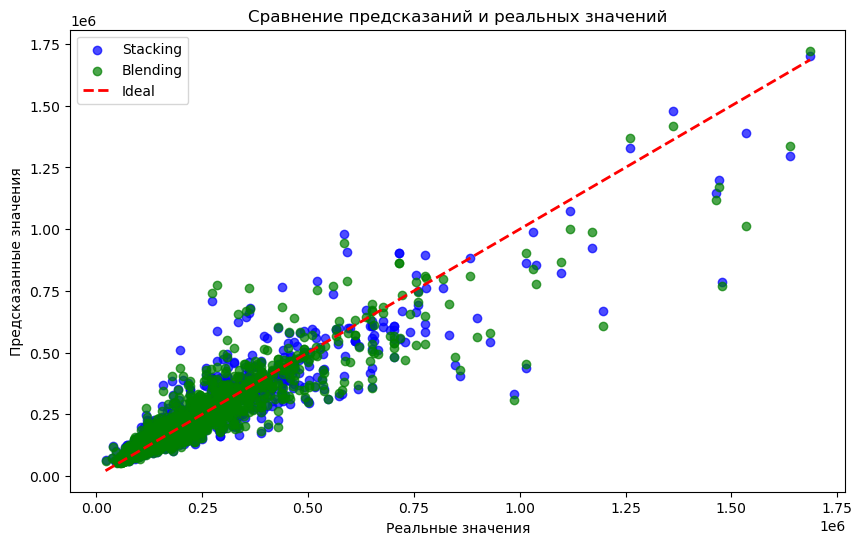

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Сравнение предсказанных и реальных значений
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stacking, alpha=0.7, color='blue', label='Stacking')
plt.scatter(y_test, y_pred_blending, alpha=0.7, color='green', label='Blending')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Сравнение предсказаний и реальных значений')
plt.legend()
plt.show()

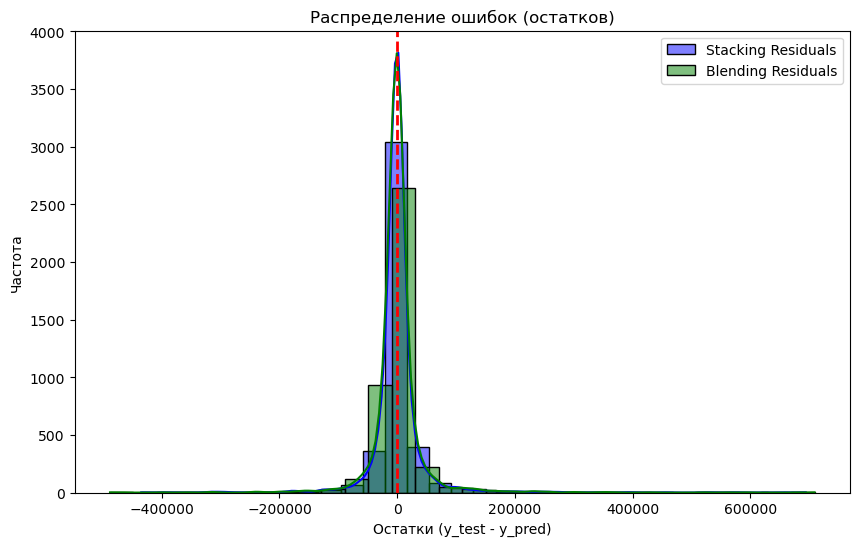

In [22]:
# Остатки (residuals)
residuals_stacking = y_test - y_pred_stacking
residuals_blending = y_test - y_pred_blending

plt.figure(figsize=(10, 6))
sns.histplot(residuals_stacking, color='blue', kde=True, label='Stacking Residuals', bins=30)
sns.histplot(residuals_blending, color='green', kde=True, label='Blending Residuals', bins=30)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Распределение ошибок (остатков)')
plt.xlabel('Остатки (y_test - y_pred)')
plt.ylabel('Частота')
plt.legend()
plt.show()


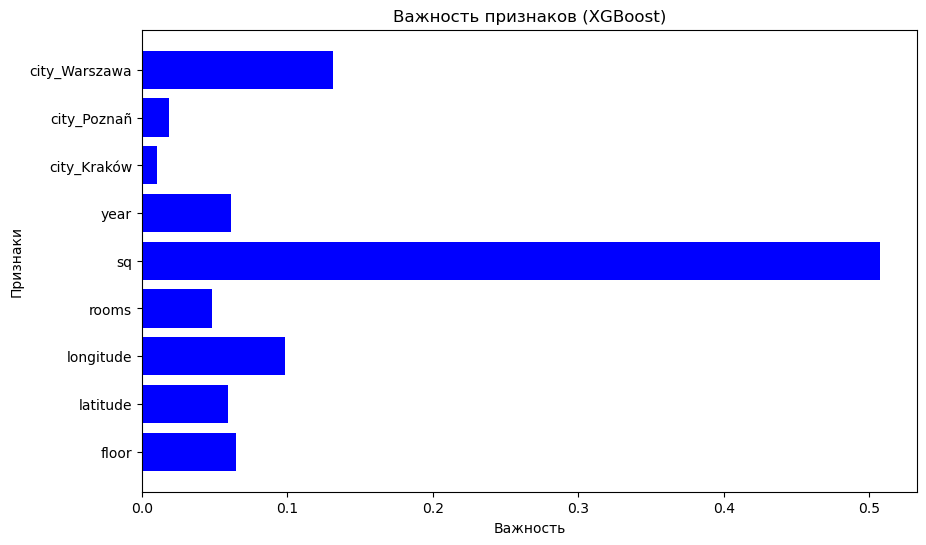

In [23]:
# Важность признаков для XGBoost
xgboost_model = [model for name, model in base_models if name == 'xgboost'][0]
xgb_importance = xgboost_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, xgb_importance, color='blue')
plt.title('Важность признаков (XGBoost)')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.show()


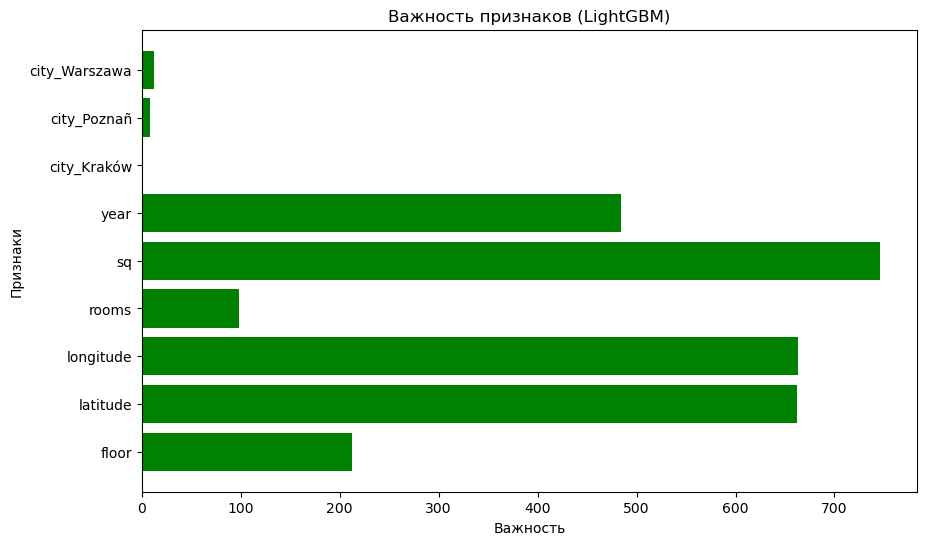

In [24]:
# Важность признаков для LightGBM
lightgbm_model = [model for name, model in base_models if name == 'lightgbm'][0]
lgb_importance = lightgbm_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, lgb_importance, color='green')
plt.title('Важность признаков (LightGBM)')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.show()